In [10]:
#=================================================================
# MINI PROJECT BIG DATA - PERTEMUAN 11
# Analitik, Korelasi, dan Regresi Linear - Implementasi Big Data
# Studi Kasus: Analisis Hubungan Jumlah Review dan Penjualan Produk Marketplace (Kategori: Kemeja)
# =================================================================

In [11]:
# IMPORT LIBRARY YANG DI BUTUHKAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

In [12]:
# ========================================================
# TAHAP 1: MENGUMPULKAN DATA
# ========================================================

# SUMBER DATA BERASAL DARI KAGGLE
# LINK-NYA: https://www.kaggle.com/datasets/pandaa12/indonesia-e-commerce-dataset-tokopedia-listings
# Saya fokus ke 1 kategori produk saja: "Kemeja", jika seluruh kategori digabung seperti elektronik, fashion,dll
# hasil korelasi/ regresi jadi bias sebab karakteristik harga & pembeli tiap kategori beda jauh

In [13]:
# MASUKKAN FILE CSV DI SINI
df = pd.read_csv('produk_tokopedia.csv')

# Filter hanya produk yang nama produknya mengandung kata "kemeja"
df_kemeja = df[df['Nama Produk'].str.contains('kemeja', case=False, na=False)].copy()
print('Jumlah produk kategori kemeja (sebelum dibersihkan):', len(df_kemeja))

Jumlah produk kategori kemeja (sebelum dibersihkan): 269


In [14]:
# ========================================================
# PEMBERSIHAN DATA
# ========================================================
# Kolom "Terjual" dan "Jumlah Ulasan" di file aslinya berupa TEKS,
# bukan angka. Contoh isinya: "1rb+ terjual", "250+ ulasan", "Unknown".
# "rb" itu singkatan "ribu" (x1000). Data perlu dikonversi ke angka
# (numerik) dulu sebelum bisa dihitung statistiknya atau dipakai
# di korelasi & regresi. Baris yang formatnya gak jelas (misal "Unknown"
# atau "ribuan terjual" tanpa angka pasti) dianggap data hilang (NaN)
# dan nanti dibuang, karena nilainya gak bisa dipastikan.

In [15]:
def parse_angka(text):
    """Mengubah teks seperti '1rb+ terjual' / '250+ ulasan' jadi angka."""
    if pd.isna(text):
        return np.nan
    text = str(text).strip().lower()
    if text in ['unknown', 'ribuan terjual', 'ribuan', '']:
        return np.nan
    text = text.replace('ulasan', '').replace('terjual', '').strip()
    if text == '':
        return np.nan
    multiplier = 1
    if 'rb' in text:          # rb = ribu = x1.000
        multiplier = 1000
        text = text.replace('rb', '')
    elif 'jt' in text:        # jt = juta = x1.000.000
        multiplier = 1_000_000
        text = text.replace('jt', '')
    text = text.replace('+', '').strip()  # tanda "+" artinya "lebih dari", diabaikan
    try:
        return float(text) * multiplier
    except ValueError:
        return np.nan

# Terjual -> variabel Y (Penjualan), Jumlah Ulasan -> variabel X (Review)
df_kemeja['Penjualan'] = df_kemeja['Terjual'].apply(parse_angka)
df_kemeja['Review']    = df_kemeja['Jumlah Ulasan'].apply(parse_angka)

# Buang baris yang gagal dikonversi (data tidak valid/hilang)
data = df_kemeja.dropna(subset=['Penjualan', 'Review']).copy()
print(f'Data final yang valid untuk dianalisis: {len(data)} dari {len(df_kemeja)} baris')
print('(Sisanya dibuang karena format datanya "Unknown"/tidak ada angka yang jelas)')


Data final yang valid untuk dianalisis: 253 dari 269 baris
(Sisanya dibuang karena format datanya "Unknown"/tidak ada angka yang jelas)


In [16]:
# ========================================================
# TAHAP 2: MENYIMPAN DATA
# ========================================================
# di simpan dalam format csv, setelah dilakukan pembersihan
# nama filenya "dataset_dashboard_penjualan_looker.csv" yang nanti akan divisualisasikan ke looker studio

data.to_csv('dataset_dahsboard_penjualan_looker.csv', index=False)
files.download('dataset_dahsboard_penjualan_looker.csv')  # otomatis download ke laptop, siap diupload ke Looker Studio

In [17]:
# ========================================================
# TAHAP 3: ANALISIS DATA - STATISTIK DESKRIPTIF
# ========================================================
# Menghitung ukuran pemusatan (mean, median, modus) dan ukuran
# penyebaran (min, max, range, standar deviasi) untuk kedua
# variabel utama: Review (X) dan Penjualan (Y).

In [18]:
print('\n=== STATISTIK DESKRIPTIF ===')
for kolom in ['Review', 'Penjualan']:
    s = data[kolom]
    print(f'\n--- Kolom: {kolom} ---')
    print('Mean (Rata-rata)   :', round(s.mean(), 2))
    print('Median (Nilai Tengah):', s.median())
    print('Modus              :', s.mode().tolist()[0] if not s.mode().empty else np.nan)
    print('Minimum            :', s.min())
    print('Maximum            :', s.max())
    print('Range (Jangkauan)  :', s.max() - s.min())
    print('Standar Deviasi    :', round(s.std(), 2))


=== STATISTIK DESKRIPTIF ===

--- Kolom: Review ---
Mean (Rata-rata)   : 2118.25
Median (Nilai Tengah): 20.0
Modus              : 0.0
Minimum            : 0.0
Maximum            : 100000.0
Range (Jangkauan)  : 100000.0
Standar Deviasi    : 11753.5

--- Kolom: Penjualan ---
Mean (Rata-rata)   : 3606.32
Median (Nilai Tengah): 50.0
Modus              : 100.0
Minimum            : 0.0
Maximum            : 100000.0
Range (Jangkauan)  : 100000.0
Standar Deviasi    : 15171.26


In [19]:
# Catatan: mean jauh lebih besar dari median pada kedua variabel.
# Ini menandakan data SANGAT SKEWED (miring) -- mayoritas produk
# kemeja penjualannya rendah, tapi ada beberapa produk "viral" dengan
# badge 100rb+ yang menarik rata-rata jadi tinggi.

In [20]:
# =================================================================
# VISUALISASI DATA (bagian dari Analitik & Visualisasi
# =================================================================
# 1. Scatter plot -> melihat pola hubungan antar 2 variabel numerik
# 2. Bar chart    -> membandingkan kategori (di sini: top 10 produk)
# 3. Pie chart    -> melihat proporsi/persentase suatu kelompok data

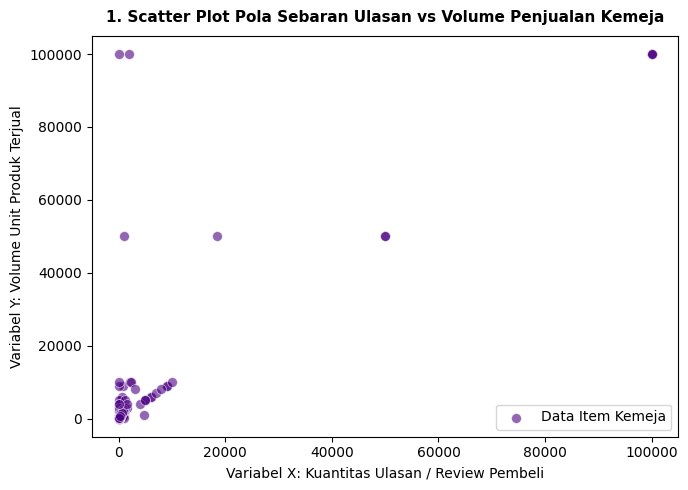

In [21]:
# 1. Scatter plot: Review vs Penjualan
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='Review', y='Penjualan', color='#4b0082', alpha=0.6, s=50, label='Data Item Kemeja')
plt.title('1. Scatter Plot Pola Sebaran Ulasan vs Volume Penjualan Kemeja', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Variabel X: Kuantitas Ulasan / Review Pembeli')
plt.ylabel('Variabel Y: Volume Unit Produk Terjual')
plt.legend()
plt.tight_layout()
plt.savefig('grafik_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

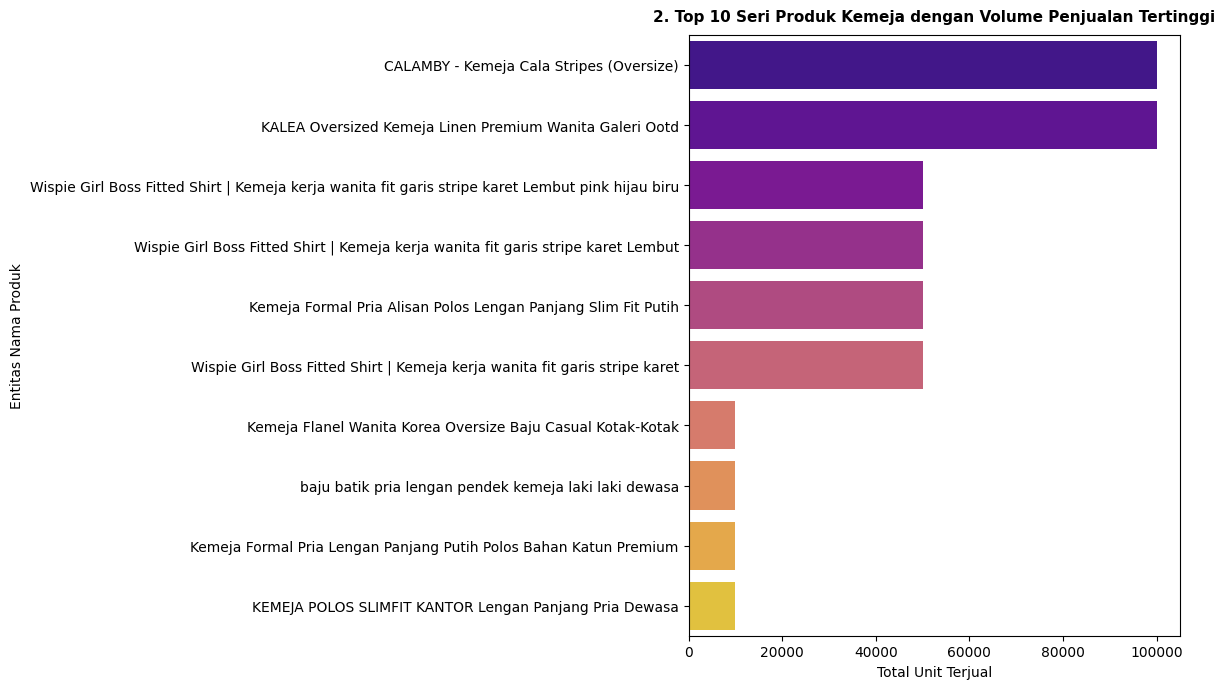

In [22]:
# 2. Bar chart: 10 produk kemeja dengan penjualan tertinggi
plt.figure(figsize=(12, 7))
top10 = data.sort_values('Penjualan', ascending=False).drop_duplicates(subset='Nama Produk', keep='first').head(10)
sns.barplot(data=top10, x='Penjualan', y='Nama Produk', palette='plasma')
plt.title('2. Top 10 Seri Produk Kemeja dengan Volume Penjualan Tertinggi', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('Total Unit Terjual')
plt.ylabel('Entitas Nama Produk')
plt.tight_layout()
plt.savefig('grafik_bar_top10.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# 3. Pie chart: proporsi produk berdasarkan tingkat jumlah review
def kategori_review(x):
    if x < 50:
        return 'Rendah (<50)'
    elif x <= 500:
        return 'Sedang (50-500)'
    else:
        return 'Tinggi (>500)'

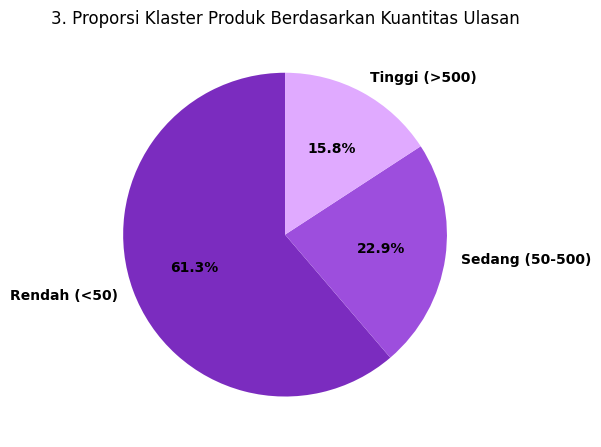

In [24]:
data['Kategori_Review'] = data['Review'].apply(kategori_review)
plt.figure(figsize=(6, 6))
data['Kategori_Review'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#7b2cbf', '#9d4edd', '#e0aaff'],
    startangle=90,
    textprops={'fontweight':'bold', 'fontsize': 10})  # Memperjelas teks persentase di dalam lingkaran
plt.title('3. Proporsi Klaster Produk Berdasarkan Kuantitas Ulasan')
plt.ylabel('')
plt.tight_layout()
plt.savefig('grafik_pie_review.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# =================================================================
# TAHAP 4: KORELASI
# =================================================================
# Korelasi Pearson mengukur ARAH dan KEKUATAN hubungan linear
# antara 2 variabel numerik. Nilainya antara -1 sampai +1.
# Interpretasi sesuai tabel di materi bu Huning:
#   0.00 - 0.19 -> Sangat Lemah     0.60 - 0.79 -> Kuat
#   0.20 - 0.39 -> Lemah            0.80 - 1.00 -> Sangat Kuat
#   0.40 - 0.59 -> Sedang

In [26]:
r = data['Review'].corr(data['Penjualan'])

def interpretasi_r(r):
    arah = 'Positif' if r > 0 else ('Negatif' if r < 0 else 'Tidak ada hubungan')
    abs_r = abs(r)
    if abs_r <= 0.19:
        kekuatan = 'Sangat Lemah'
    elif abs_r <= 0.39:
        kekuatan = 'Lemah'
    elif abs_r <= 0.59:
        kekuatan = 'Sedang'
    elif abs_r <= 0.79:
        kekuatan = 'Kuat'
    else:
        kekuatan = 'Sangat Kuat'
    return arah, kekuatan

arah, kekuatan = interpretasi_r(r)
print('\n=== HASIL KORELASI PEARSON ===')
print('Nilai korelasi (r):', round(r, 4))
print(f'Interpretasi: Hubungan {arah}, kategori {kekuatan}')
# Ingat: korelasi cuma menunjukkan keterkaitan, BUKAN hubungan sebab-akibat.



=== HASIL KORELASI PEARSON ===
Nilai korelasi (r): 0.7768
Interpretasi: Hubungan Positif, kategori Kuat


In [27]:
# =================================================================
# TAHAP 5 & 6: REGRESI LINEAR & PREDIKSI
# =================================================================
# Model regresi linear sederhana: Y = a + bX
#   Y = Penjualan (variabel yang diprediksi / dependen)
#   X = Review    (variabel predictor / independen)
#   a = intercept (estimasi Y saat X = 0)
#   b = slope     (besar kenaikan Y untuk setiap kenaikan 1 unit X)

In [28]:
X = data[['Review']]
y = data['Penjualan']

model = LinearRegression().fit(X, y)
a = model.intercept_
b = model.coef_[0]
r2 = model.score(X, y)  # R-squared: seberapa besar variasi Y yang bisa dijelaskan oleh X

print('\n=== HASIL REGRESI LINEAR ===')
print(f'Persamaan regresi: Y = {a:.2f} + {b:.4f}X')
print(f'R-squared (R²): {r2:.4f}  (artinya X menjelaskan {r2*100:.1f}% variasi Y)')

# Contoh prediksi - ganti angka ini sesuai kebutuhan analisismu
review_baru = 300
prediksi = model.predict([[review_baru]])[0]
prediksi = max(0, prediksi)  # proteksi: penjualan gak mungkin nilainya negatif
print(f'\nPrediksi penjualan jika produk punya {review_baru} review: {prediksi:.0f} unit')


=== HASIL REGRESI LINEAR ===
Persamaan regresi: Y = 1482.37 + 1.0027X
R-squared (R²): 0.6034  (artinya X menjelaskan 60.3% variasi Y)

Prediksi penjualan jika produk punya 300 review: 1783 unit


In [29]:
# =================================================================
# TAHAP 7: INSIGHT (Insight & Pengambilan Keputusan)
# =================================================================
# Menjawab 3 pertanyaan analisis yang ada di materi
# hasil korelasi & regresi yang sudah dihitung di atas

In [30]:
print('\n=== A. MENJAWAB 3 PERTANYAAN ANALISIS ===')
print(f"""
1. Apakah semakin banyak review maka semakin tinggi penjualan?
   Ya. Nilai korelasi (r = {r:.4f}) dan slope regresi (b = {b:.4f})
   sama-sama bertanda positif, artinya kenaikan jumlah review
   cenderung diikuti kenaikan penjualan.

2. Seberapa kuat hubungan antara jumlah review dan penjualan?
   r = {r:.4f} masuk kategori "{kekuatan}" menurut tabel interpretasi
   pada materi (rentang 0.60-0.79 untuk kategori Kuat).

3. Bisakah kita memprediksi penjualan berdasarkan jumlah review?
   Bisa, menggunakan persamaan Y = {a:.2f} + {b:.4f}X. R-squared
   = {r2:.4f} artinya jumlah review menjelaskan {r2*100:.1f}% variasi
   penjualan. Catatan penting: korelasi dan regresi ini menunjukkan
   POLA KECENDERUNGAN, bukan hubungan sebab-akibat (kausalitas) yang
   mutlak -- review yang banyak belum tentu jadi satu-satunya
   penyebab penjualan tinggi, bisa jadi keduanya sama-sama didorong
   faktor lain seperti kualitas produk atau popularitas brand.
""")

# --- Insight tambahan: dihitung langsung dari pola data, bukan dugaan ---
proporsi_review = data['Kategori_Review'].value_counts(normalize=True).mul(100).round(1)

ambang_outlier = 50000
produk_dominan = data[(data['Review'] >= ambang_outlier) | (data['Penjualan'] >= ambang_outlier)]
jumlah_dominan = len(produk_dominan)
kontribusi_dominan_pct = round(produk_dominan['Penjualan'].sum() / data['Penjualan'].sum() * 100, 1)
jumlah_duplikat = int(data['Nama Produk'].duplicated().sum())
print('=== B. INSIGHT TAMBAHAN DARI POLA DATA ===')
print(f"""
1. Distribusi datanya sangat timpang (skewed). Mean Penjualan
   ({data['Penjualan'].mean():.0f}) jauh lebih besar dari Median ({data['Penjualan'].median():.0f}).
   Artinya mayoritas produk penjualannya kecil, tapi ada segelintir
   produk "viral" yang menarik nilai rata-rata jadi tinggi.

2. Sebagian besar produk kemeja ({proporsi_review.get('Rendah (<50)', 0)}%) masih punya
   jumlah review di bawah 50, sementara hanya {proporsi_review.get('Tinggi (>500)', 0)}%
   yang reviewnya di atas 500. Artinya banyak seller belum optimal
   mengumpulkan review, padahal variabel ini terbukti berkorelasi
   kuat dengan penjualan.

3. Penjualan kategori kemeja ini cukup terkonsentrasi: hanya
   {jumlah_dominan} dari {len(data)} produk (dengan review atau penjualan
   di atas {ambang_outlier:,}) yang menyumbang sekitar {kontribusi_dominan_pct}%
   dari total penjualan kategori. Catatan: ada {jumlah_duplikat} baris
   dengan nama produk yang sama tercatat berulang di dataset
   (kemungkinan hasil crawling di waktu berbeda), jadi angka
   kontribusi ini perlu dibaca sebagai estimasi, bukan angka pasti.

4. R-squared model hanya {r2*100:.1f}%, artinya {100-r2*100:.1f}% variasi
   penjualan dijelaskan faktor lain di luar jumlah review --
   kemungkinan harga, rating, atau strategi promosi yang belum
   dimasukkan ke dalam model ini.
""")



=== A. MENJAWAB 3 PERTANYAAN ANALISIS ===

1. Apakah semakin banyak review maka semakin tinggi penjualan?
   Ya. Nilai korelasi (r = 0.7768) dan slope regresi (b = 1.0027)
   sama-sama bertanda positif, artinya kenaikan jumlah review
   cenderung diikuti kenaikan penjualan.

2. Seberapa kuat hubungan antara jumlah review dan penjualan?
   r = 0.7768 masuk kategori "Kuat" menurut tabel interpretasi
   pada materi (rentang 0.60-0.79 untuk kategori Kuat).

3. Bisakah kita memprediksi penjualan berdasarkan jumlah review?
   Bisa, menggunakan persamaan Y = 1482.37 + 1.0027X. R-squared
   = 0.6034 artinya jumlah review menjelaskan 60.3% variasi
   penjualan. Catatan penting: korelasi dan regresi ini menunjukkan
   POLA KECENDERUNGAN, bukan hubungan sebab-akibat (kausalitas) yang
   mutlak -- review yang banyak belum tentu jadi satu-satunya
   penyebab penjualan tinggi, bisa jadi keduanya sama-sama didorong
   faktor lain seperti kualitas produk atau popularitas brand.

=== B. INSIGHT TAMBAH

In [31]:
# =================================================================
# TAHAP 8: KEPUTUSAN BISNIS (Insight & Pengambilan Keputusan)
# -----------------------------------------------------------------
print("""=== REKOMENDASI KEPUTUSAN BISNIS ===
1. Dorong pembeli memberikan review (misal insentif cashback atau
   diskon ongkir setelah memberi ulasan), karena review terbukti
   berkorelasi kuat dengan penjualan.
2. Untuk produk dengan review masih rendah (mayoritas kasus di
   kategori ini), jangan cuma mengandalkan review -- optimalkan dulu
   harga, foto produk, dan iklan untuk membangun penjualan awal
   sambil review terkumpul secara bertahap.
3. Pelajari pola produk-produk yang penjualannya jauh di atas
   rata-rata, lalu coba replikasi unsur yang berhasil (judul produk,
   desain, harga) ke produk lain yang sejenis.
4. Pakai persamaan regresi sebagai ESTIMASI AWAL proyeksi penjualan
   saat sebuah produk mulai mengumpulkan review, untuk bantu
   perencanaan stok -- tapi tetap beri margin aman karena model ini
   baru menjelaskan sekitar 60% variasi penjualan.
5. Untuk analisis lanjutan (misal di skripsi atau project berikutnya),
   sertakan variabel lain seperti harga dan rating supaya model
   prediksi penjualan bisa lebih akurat.
""")


=== REKOMENDASI KEPUTUSAN BISNIS ===
1. Dorong pembeli memberikan review (misal insentif cashback atau
   diskon ongkir setelah memberi ulasan), karena review terbukti
   berkorelasi kuat dengan penjualan.
2. Untuk produk dengan review masih rendah (mayoritas kasus di
   kategori ini), jangan cuma mengandalkan review -- optimalkan dulu
   harga, foto produk, dan iklan untuk membangun penjualan awal
   sambil review terkumpul secara bertahap.
3. Pelajari pola produk-produk yang penjualannya jauh di atas
   rata-rata, lalu coba replikasi unsur yang berhasil (judul produk,
   desain, harga) ke produk lain yang sejenis.
4. Pakai persamaan regresi sebagai ESTIMASI AWAL proyeksi penjualan
   saat sebuah produk mulai mengumpulkan review, untuk bantu
   perencanaan stok -- tapi tetap beri margin aman karena model ini
   baru menjelaskan sekitar 60% variasi penjualan.
5. Untuk analisis lanjutan (misal di skripsi atau project berikutnya),
   sertakan variabel lain seperti harga dan rating supaya

In [32]:
# Download otomatis ketiga file grafik (PNG) buat ditempel di laporan PDF & slide presentasi
for nama_file in ['grafik_scatter.png', 'grafik_bar_top10.png', 'grafik_pie_review.png']:
    files.download(nama_file)